In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as pl
from matplotlib import rcParams 
import scanpy as sc
import scanpy.external as sce
import scanpy as sc
import anndata
from scipy import io
from scipy.sparse import coo_matrix, csr_matrix
import os
import scvelo as scv


In [5]:
X = io.mmread("20251210_escc_squamous_final_metadata.mtx")


In [6]:
adata_harmony = anndata.AnnData(
  X=X.transpose().tocsr()
)

In [7]:
cell_meta = pd.read_csv("20251210_escc_squamous_final_metadata.csv")

In [8]:
with open("20251210_escc_squamous_final_gene_names.csv", 'r') as f:
  gene_names = f.read().splitlines()

In [9]:
adata_harmony.obs = cell_meta
adata_harmony.obs.index = adata_harmony.obs['barcode']
adata_harmony.var.index = gene_names

In [10]:
pca = pd.read_csv("20251210_escc_squamous_final_pca.csv")
pca.index = adata_harmony.obs.index
harmony = pd.read_csv("20251210_escc_squamous_final_harmony.csv")
harmony.index = adata_harmony.obs.index

In [11]:
adata_harmony.obsm['X_pca'] = pca.to_numpy()
adata_harmony.obsm['X_harmony'] = pca.to_numpy()
adata_harmony.obsm['X_umap'] = np.vstack((adata_harmony.obs['UMAP_1'].to_numpy(), adata_harmony.obs['UMAP_2'].to_numpy())).T

In [ ]:
adata_harmony.obs['paga_v1']=adata_harmony.obs['Annotation_v3'].astype(str).astype('category')
sc.pl.umap(adata_harmony, color='paga_v1')

In [ ]:
sc.pl.umap(adata_harmony, color='subcluster')

In [14]:
adata_harmony.write('20251210_squamous_final_adata_hj.h5ad')

In [15]:
# run paga
sc.pp.neighbors(adata_harmony, n_pcs = 15, n_neighbors = 10, use_rep = 'X_harmony', method='umap')

In [ ]:
sc.tl.paga(adata_harmony, groups = 'subcluster')
sc.pl.paga(adata_harmony, color = 'subcluster')

In [ ]:
scv.pl.paga(adata_harmony, basis = 'umap', color = 'subcluster', transitions=None, threshold=0.12,
            palette={"0_0": "#F8766D",
                    "0_1": "#F8766D",
                    "0_2": "#F8766D",
                    "0_3": "#F8766D",
                    "1_0" : "#0CB702",
                    "1_1" : "#0CB702",
                    "1_2" : "#0CB702",
                    "1_3" : "#0CB702",
                    "2" : "#00167C",
                    "3" : "#F323E5",
                    "4": "#EEBE31",
                    "5_0" : "#619CFF",
                    "5_1" : "#619CFF"},
            save = '20250810_paga_connection_squamous_fdl_multi_nodes_color_n10_sk.pdf')

In [19]:
scv.settings.verbosity = 3
scv.settings.presenter_view = True
scv.set_figure_params(style='scvelo')

In [49]:
adata = sc.read_h5ad("/Users/hojin/Downloads/20250809_merged_squamous_ldata_dl.h5ad")

In [50]:
color_key = "Annotation_v3" if "Annotation_v3" in adata.obs.columns else (
    "celltype" if "celltype" in adata.obs.columns else None
)

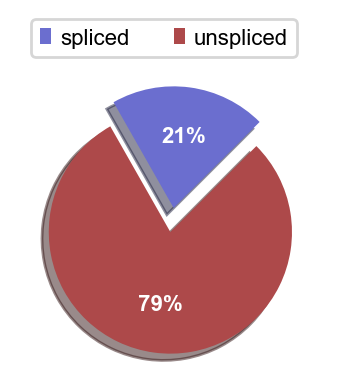

In [51]:
scv.pl.proportions(adata)

In [ ]:
adata_harmony = sc.read_h5ad("20251210_squamous_final_adata_hj.h5ad")

# obs_names (cell barcodes) comparison
common = np.intersect1d(adata.obs_names, adata_harmony.obs_names)

print("adata cells:", adata.n_obs)
print("harmony adata cells:", adata_harmony.n_obs)
print("common cells:", len(common))
print("overlap ratio:", len(common) / adata.n_obs)

rep_key = "X_harmony" 

# make barcode to embedding dict
bc_to_emb = {
    bc: adata_harmony.obsm[rep_key][i]
    for i, bc in enumerate(adata_harmony.obs["barcode"].values)
}

n_pcs = adata_harmony.obsm[rep_key].shape[1]
adata.obsm[rep_key] = np.zeros((adata.n_obs, n_pcs))

missing = 0
for i, bc in enumerate(adata.obs["barcode"].values):
    if bc in bc_to_emb:
        adata.obsm[rep_key][i] = bc_to_emb[bc]
    else:
        missing += 1

adata cells: 40350
harmony adata cells: 40434
common cells: 0
overlap ratio: 0.0


In [53]:
fdl_key = "X_umap"
key = "barcode"

h = adata_harmony.obs.reset_index(drop=True)[[key]].copy() # reset index and select barcode
h["i_h"] = np.arange(adata_harmony.n_obs) 
v = adata.obs.reset_index(drop=True)[[key]].copy()
v["i_v"] = np.arange(adata.n_obs)
m = v.merge(h, on=key, how="inner")

adata.obsm[fdl_key] = np.full((adata.n_obs, adata_harmony.obsm[fdl_key].shape[1]), np.nan)
adata.obsm[fdl_key][m["i_v"].values] = adata_harmony.obsm[fdl_key][m["i_h"].values]

print("mapped cells:", m.shape[0], "/", adata.n_obs)


mapped cells: 40350 / 40350


computing moments based on connectivities
    finished (0:00:05) --> added 
    'Ms' and 'Mu', moments of un/spliced abundances (adata.layers)
computing velocities
    finished (0:00:04) --> added 
    'velocity', velocity vectors for each individual cell (adata.layers)
computing velocity graph (using 1/12 cores)


  0%|          | 0/40350 [00:00<?, ?cells/s]

    finished (0:00:45) --> added 
    'velocity_graph', sparse matrix with cosine correlations (adata.uns)
computing velocity embedding
    finished (0:00:09) --> added
    'velocity_umap', embedded velocity vectors (adata.obsm)


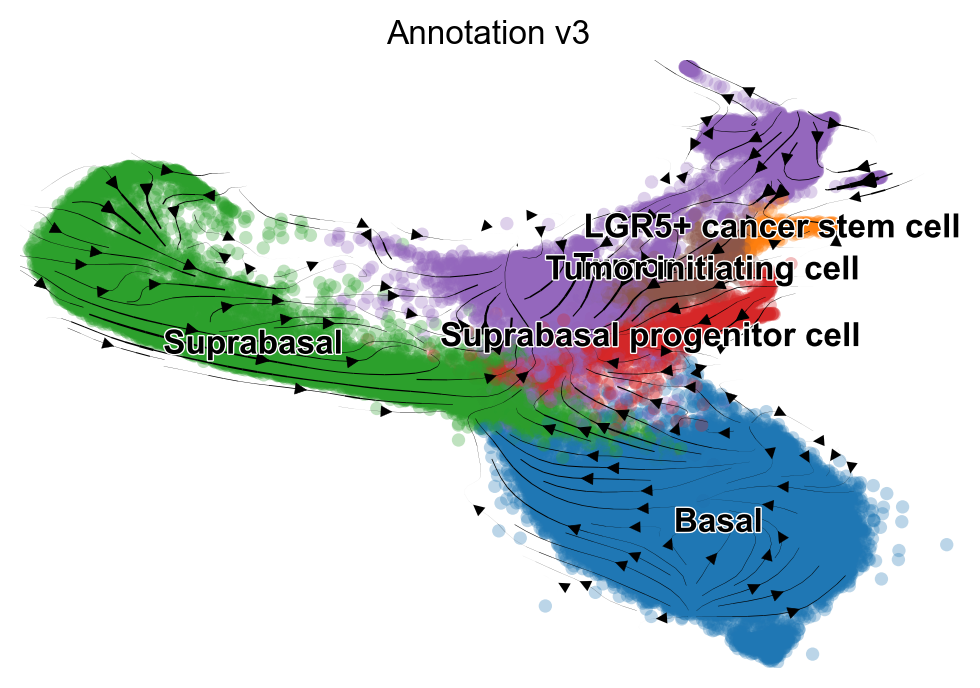

In [ ]:
# 1. neighbors (PCA/Harmony)
sc.pp.neighbors(adata, use_rep="X_harmony", n_neighbors=15)

# 2. moments
scv.pp.moments(adata, n_neighbors=None, n_pcs=None)

# 3. velocity
scv.tl.velocity(adata, mode="steady_state")  # or dynamical

# 4. velocity graph
scv.tl.velocity_graph(adata)

scv.pl.velocity_embedding_stream(
    adata,
    basis="umap",
    color="Annotation_v3"
)


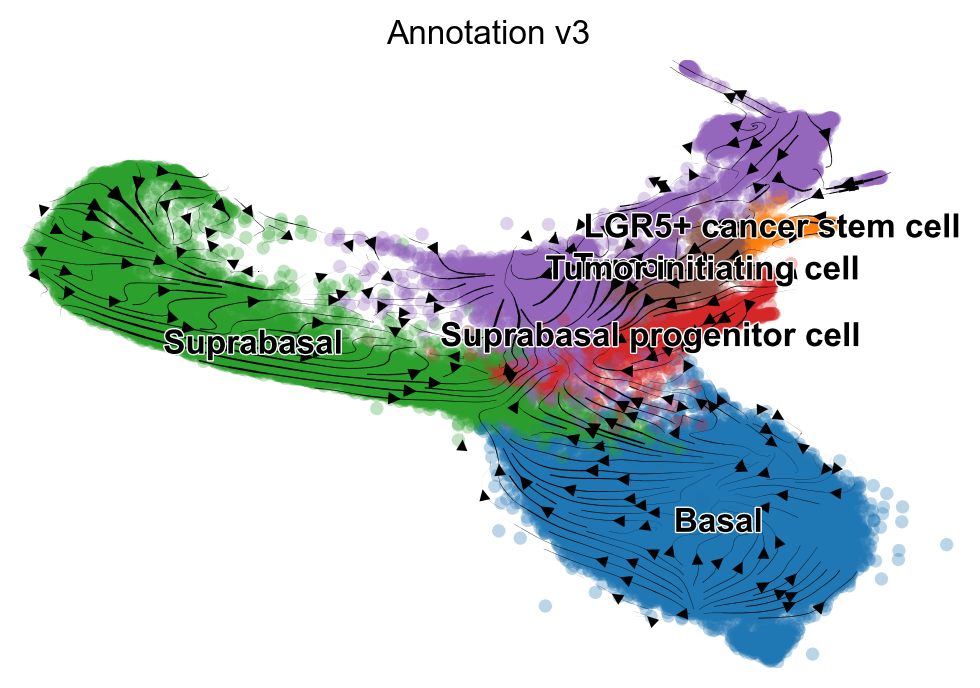

In [63]:
scv.pl.velocity_embedding_stream(
    adata,
    basis="umap",
    color="Annotation_v3",
    smooth=0.3,
    density=3.0,
    min_mass=0.1
)

In [64]:
col = 'subcluster'
adata.obs_names = adata.obs['barcode'].astype(str)
shared = adata.obs_names.intersection(adata_harmony.obs_names)
print("shared cells:", len(shared), "/", adata.n_obs)

adata.obs['subcluster'] = pd.NA
adata.obs.loc[shared, 'subcluster'] = (
    adata_harmony.obs.loc[shared, 'subcluster']
    .astype("object")
)

adata.obs['subcluster'] = adata.obs['subcluster'].astype('category')

shared cells: 40350 / 40350


In [63]:
adata.write("20251214_squamous_velocity_adata_hj.h5ad")

In [69]:
adata = sc.read_h5ad("20251214_squamous_velocity_adata_hj.h5ad")

In [ ]:
# category to string
adata.obs["Annotation_v3"] = adata.obs["Annotation_v3"].astype(str)

adata.obs["Annotation_v3"] = adata.obs["Annotation_v3"].replace(
    {"Suprabasal progenitor cell": "Transitional suprabasal"}
)
adata.obs["Annotation_v3"] = adata.obs["Annotation_v3"].astype("category")

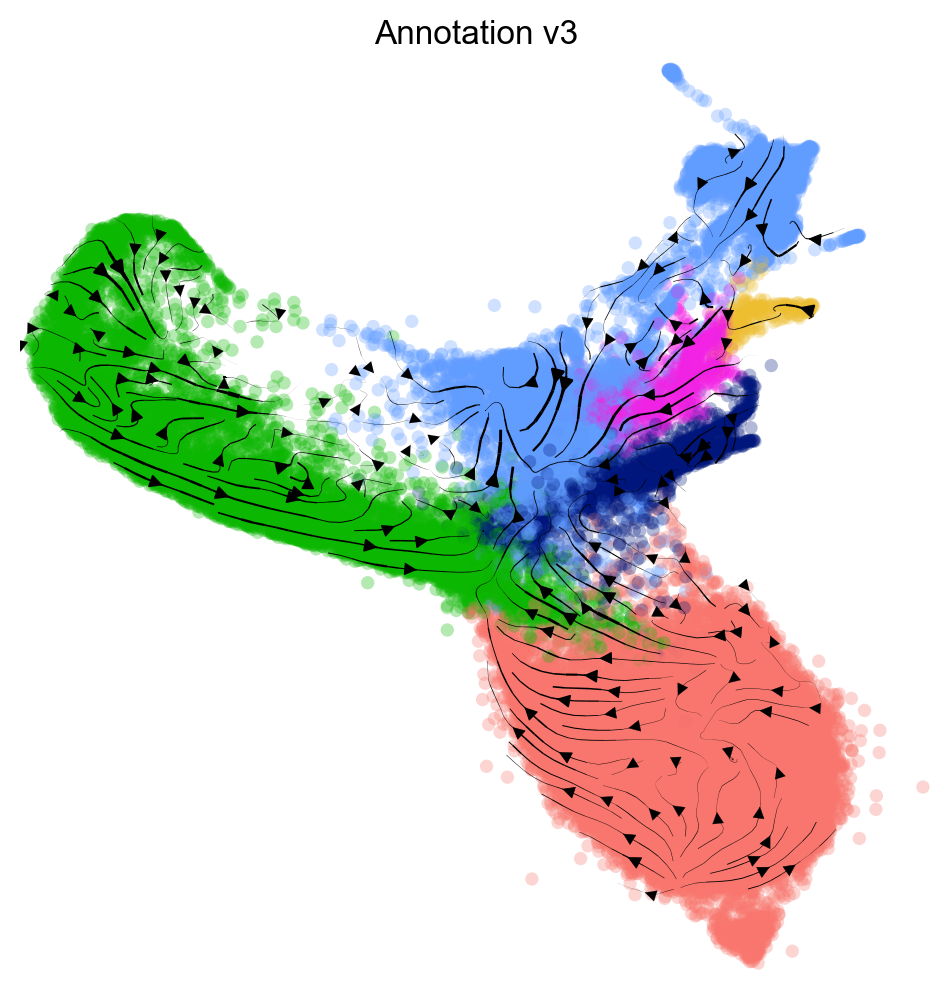

In [ ]:
import matplotlib.pyplot as plt
import scvelo as scv

fig, ax = plt.subplots(figsize=(6, 6))

# velocity stream plot
scv.pl.velocity_embedding_stream(
    adata,
    basis="umap",
    color="Annotation_v3",
    palette={"Basal": "#F8766D",
             "LGR5+ cancer stem cell": "#EEBE31",
             "Suprabasal" : "#0CB702",
             "Transitional suprabasal" : "#00167C",
             "Tumor" : "#619CFF",
             "Tumor initiating cell" : "#F323E5"
             },
    smooth=0.2,
    density=2.5,
    min_mass=0.05,
    legend_loc=None,   # ← annotation(범례) 제거
    ax=ax,
    show=False
)

for txt in ax.texts:
    txt.set_visible(False)

ax.set_box_aspect(1)
ax.set_xticks([]); ax.set_yticks([])

fig.savefig("velocity_stream_square.pdf", dpi=300) 
plt.show()

In [ ]:
T = scv.tl.transition_matrix(
    adata,
    basis="umap",
    backward=False
)

#Td = T.A if hasattr(T, "A") else np.asarray(T)

In [ ]:
clusters = adata.obs["Annotation_v3"].astype(str).values
cats = pd.Index(sorted(pd.unique(clusters)))
idx = {c:i for i,c in enumerate(cats)}

C = np.zeros((len(cats), len(cats)), dtype=float)

for i in range(T.shape[0]):
    row = T.getrow(i)
    ci = clusters[i]
    ci_idx = idx[ci]
    for j, v in zip(row.indices, row.data):
        C[ci_idx, idx[clusters[j]]] += v

C = C / (C.sum(axis=1, keepdims=True) + 1e-12)

T_clust = pd.DataFrame(C, index=cats, columns=cats)
T_clust

,Basal,LGR5+ cancer stem cell,Suprabasal,Transitional suprabasal,Tumor,Tumor initiating cell
Basal,0.992533,0.000000,0.006466,0.000275,0.000715,1.136831e-05
LGR5+ cancer stem cell,0.000000,0.867721,0.000000,0.000019,0.032684,9.957625e-02
Suprabasal,0.012712,0.000000,0.972035,0.010182,0.005072,4.477207e-08
Transitional suprabasal,0.002347,0.002412,0.083830,0.861449,0.027751,2.221078e-02
Tumor,0.003825,0.000398,0.007532,0.001973,0.980918,5.353331e-03
Tumor initiating cell,0.000906,0.024970,0.000059,0.064645,0.198893,7.105276e-01


In [24]:
topk = 4
for c in T_clust.index:
    s = T_clust.loc[c].sort_values(ascending=False)
    print(c, "->", list(s.index[:topk]), ":", list(np.round(s.values[:topk], 3)))

Basal -> ['Basal', 'Suprabasal', 'Tumor', 'Transitional suprabasal'] : [0.993, 0.006, 0.001, 0.0]
LGR5+ cancer stem cell -> ['LGR5+ cancer stem cell', 'Tumor initiating cell', 'Tumor', 'Transitional suprabasal'] : [0.868, 0.1, 0.033, 0.0]
Suprabasal -> ['Suprabasal', 'Basal', 'Transitional suprabasal', 'Tumor'] : [0.972, 0.013, 0.01, 0.005]
Transitional suprabasal -> ['Transitional suprabasal', 'Suprabasal', 'Tumor', 'Tumor initiating cell'] : [0.861, 0.084, 0.028, 0.022]
Tumor -> ['Tumor', 'Suprabasal', 'Tumor initiating cell', 'Basal'] : [0.981, 0.008, 0.005, 0.004]
Tumor initiating cell -> ['Tumor initiating cell', 'Tumor', 'Transitional suprabasal', 'LGR5+ cancer stem cell'] : [0.711, 0.199, 0.065, 0.025]


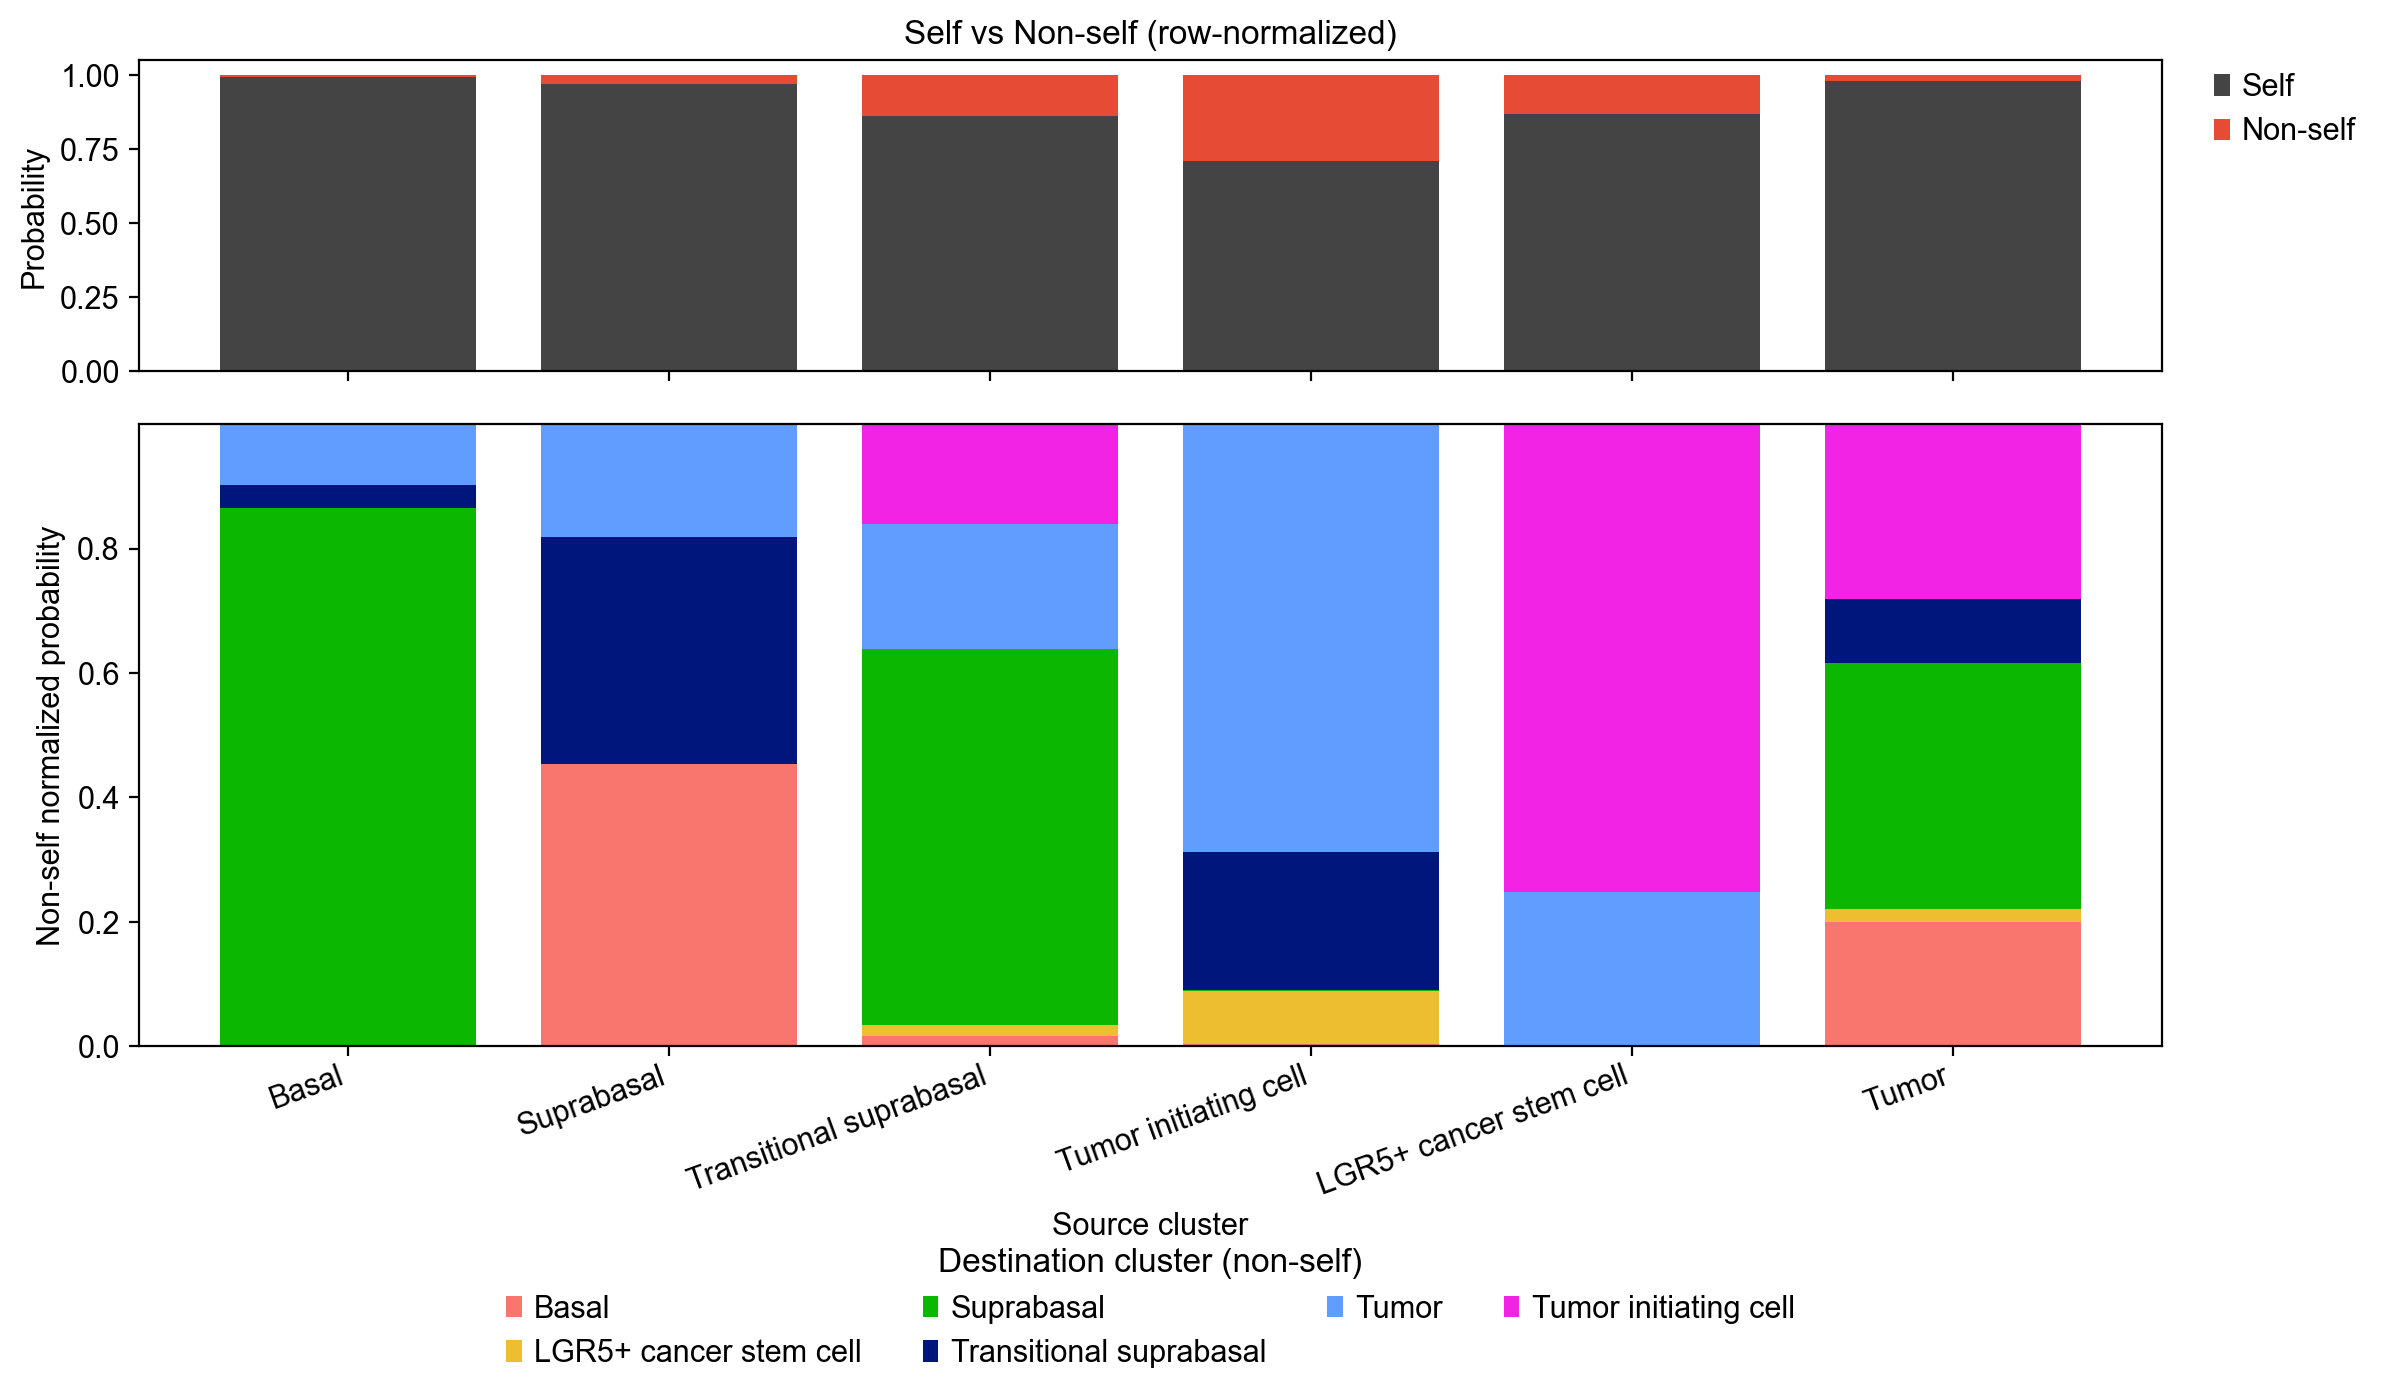

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

T = T_clust.copy()

row_sum0 = T.sum(axis=1).replace(0, np.nan)
Tprob = T.div(row_sum0, axis=0).fillna(0)

self_p = pd.Series(np.diag(Tprob.values), index=Tprob.index, name="Self")
nonself_p = 1.0 - self_p
A = pd.DataFrame({"Self": self_p, "Non-self": nonself_p})

T_noself = Tprob.copy()
np.fill_diagonal(T_noself.values, 0.0)

row_sum_ns = T_noself.sum(axis=1).replace(0, np.nan)
Tn = T_noself.div(row_sum_ns, axis=0).fillna(0)   # non-self sum = 1

# top 6
K = 6
Tn_top = Tn.apply(lambda r: r.where(r.rank(ascending=False) <= K, 0), axis=1)

order = [
    "Basal",
    "Suprabasal",
    "Transitional suprabasal",
    "Tumor initiating cell",
    "LGR5+ cancer stem cell",
    "Tumor",
]

order = [c for c in order if c in Tprob.index]

A = A.reindex(order)
Tn_top = Tn_top.reindex(order)

palette = {"Basal": "#F8766D",
             "LGR5+ cancer stem cell": "#EEBE31",
             "Suprabasal" : "#0CB702",
             "Transitional suprabasal" : "#00167C",
             "Tumor" : "#619CFF",
             "Tumor initiating cell" : "#F323E5"
}

colors_dest = [palette.get(c, "#BBBBBB") for c in Tn_top.columns]

# plotting
fig, (ax1, ax2) = plt.subplots(
    2, 1, figsize=(12, 7),
    gridspec_kw={"height_ratios": [1, 2]},
    sharex=True
)

# Plot A: Self vs Non-self
A.plot(kind="bar", stacked=True, ax=ax1, color=["#444444", "#E64B35"], width=0.8)
ax1.set_ylabel("Probability")
ax1.set_title("Self vs Non-self (row-normalized)")
#ax1.legend(loc="upper right", frameon=False)

ax1.legend(
    loc="upper left",          
    bbox_to_anchor=(1.02, 1.0)
    frameon=False,
    borderaxespad=0.0
)

# Plot B: Non-self breakdown by destination
Tn_top.plot(kind="bar", stacked=True, ax=ax2, color=colors_dest, width=0.8)
ax2.set_ylabel("Non-self normalized probability")
ax2.set_xlabel("Source cluster")
ax2.set_xticklabels(ax2.get_xticklabels(), rotation=20, ha="right")

# legend 
ax2.legend(
    title="Destination cluster (non-self)",
    loc="upper center",
    bbox_to_anchor=(0.5, -0.28),
    ncol=4,
    frameon=False
)

ax2.tick_params(axis="x", pad=2)
plt.subplots_adjust(bottom=0.30)
plt.tight_layout()
plt.show()

fig.savefig(
    "20250810_transition_self_nonself_and_nonself_breakdown.pdf",
    dpi=300
)

plt.close(fig)